Library

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Path

In [2]:
# Resize all images to a common size
img_size = (64, 64)

# Set dataset path
dataset_path = 'data'  # Change this!

Load Resize Grayscale HOG

In [3]:
data = []
labels = []

# Loop through each class folder
for label_index, class_name in enumerate(os.listdir(dataset_path)):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        continue

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        # Read image as grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue  # Skip unreadable images

        img_resized = cv2.resize(img, img_size)

        # Extract HOG features
        features = hog(img_resized,
                       orientations=9,
                       pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2),
                       visualize=False,
                       block_norm='L2-Hys')
        data.append(features)
        labels.append(label_index)

Convert to numpy array

In [4]:
X = np.array(data)
y = np.array(labels)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (391, 1764)
Labels shape: (391,)


Split dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

SVM

SVM Accuracy: 0.7468354430379747
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77        44
           1       0.71      0.71      0.71        35

    accuracy                           0.75        79
   macro avg       0.74      0.74      0.74        79
weighted avg       0.75      0.75      0.75        79



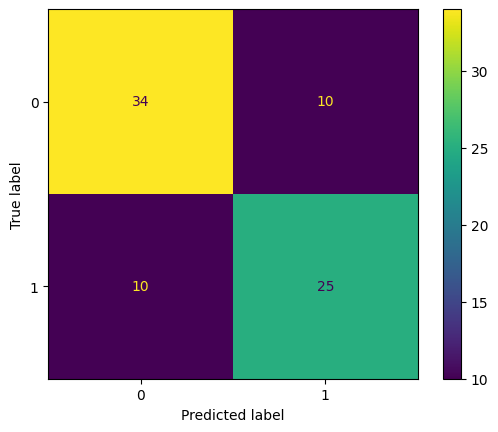

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("SVM Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)

Predict New Image

In [7]:
def predict_image(img_path, model):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, img_size)
    features, _ = hog(img_resized,
                      orientations=9,
                      pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2),
                      visualize=True,
                      block_norm='L2-Hys')
    features = np.array(features).reshape(1, -1)
    prediction = model.predict(features)
    return prediction[0]


# Example usage
result = predict_image('data/tomato/tomato (15).jpeg', svm_model)
print("Predicted class:", result)

Predicted class: 1


KNN

KNN Accuracy: 0.6455696202531646
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.55      0.63        44
           1       0.57      0.77      0.66        35

    accuracy                           0.65        79
   macro avg       0.66      0.66      0.65        79
weighted avg       0.67      0.65      0.64        79



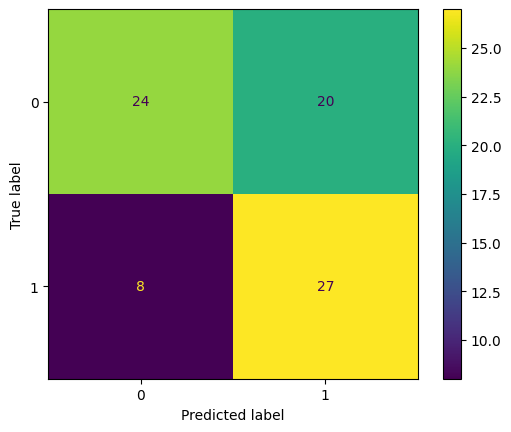

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_test)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("KNN Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)

Random Forest

Random Forest Accuracy: 0.6708860759493671
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72        44
           1       0.65      0.57      0.61        35

    accuracy                           0.67        79
   macro avg       0.67      0.66      0.66        79
weighted avg       0.67      0.67      0.67        79



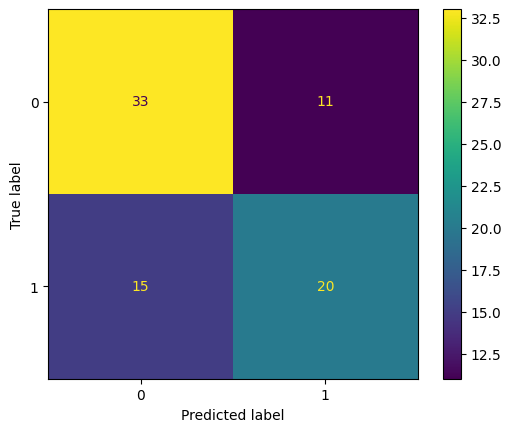

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Classification Report:\n",
      classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

Logistic Regression

Logistic Regression Accuracy: 0.6962025316455697
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73        44
           1       0.66      0.66      0.66        35

    accuracy                           0.70        79
   macro avg       0.69      0.69      0.69        79
weighted avg       0.70      0.70      0.70        79



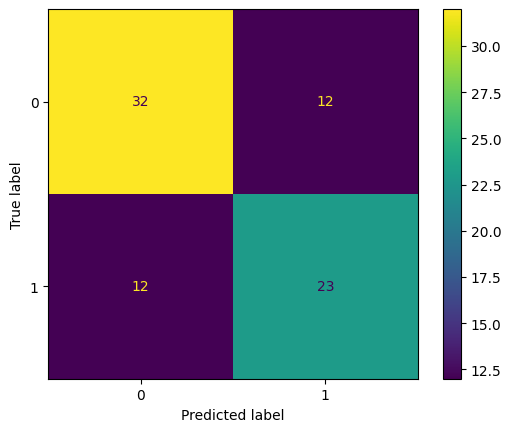

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Classification Report:\n",
      classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test)

Naive Bayes

Naive Bayes Accuracy: 0.6455696202531646
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.55      0.63        44
           1       0.57      0.77      0.66        35

    accuracy                           0.65        79
   macro avg       0.66      0.66      0.65        79
weighted avg       0.67      0.65      0.64        79



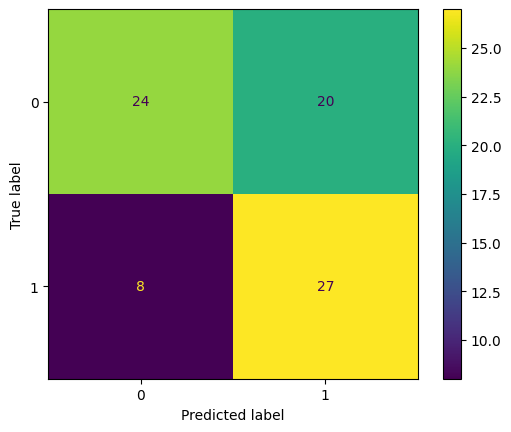

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)

# Evaluate
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Classification Report:\n",
      classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(nb_model, X_test, y_test)